<a href="https://colab.research.google.com/github/gakbn/ESCB-AngelGabrielAndradeAmezcua/blob/main/Lab07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generación, limpieza y transformación de un DataSet el principio GIGO

Fecha: 28 de mayo del 2026

Autor: Maria Reina Zarate Nava

# Objetivo general
identificar problemas de calidad de datos,aplicar técnicas de limpieza y transformación,
y analizar cómo los datos incorrectos afectan el análisis y los modelos de Machine Learning mediante el principio GIGO.

# Actividad

Identifique y documente:

- Valores nulos
- Outliers (Negativos o fuera de rango)
- Datos inválidos
- Facturas canceladas ( identificadas con la letra c)
- Duplicados
- Problemas de formato o tipo de datos (Fechas o Monto)

Posteriormente:

- Limpie el dataset
- Transforme los datos
- Justifique las decisiones tomadas
- Explique cómo afecta el principio GIGO al análisis de datos y Machine Learning

# Graficas solicitadas para la identificación de anomalias
1. Ventas por pais
2. Heatmap de valores nulos
3. Distribución del monto

# Nota:
Al terminar exportar el dataset limpio a formato csv y subir junto con el Laboratorio a GitHub, cumpliendo  con la siguiente estructura.

    - Notebooks (Folder)
        - Lab07.ipynb
    - DataSet (Folder)
        - Data_Limpio_Factura.csv

In [8]:
import pandas as pd

In [9]:
import numpy as np

In [10]:
import matplotlib.pyplot as plt

In [11]:
import seaborn as sns

In [12]:
df = pd.read_csv('ventas-por-factura.csv')

In [13]:
display(df.head())

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,"229,33"
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,"209,73"
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,"39,95"
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,"344,83"


In [14]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25953 entries, 0 to 25952
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   N° de factura     25953 non-null  object 
 1   Fecha de factura  25953 non-null  object 
 2   ID Cliente        22229 non-null  float64
 3   País              25953 non-null  object 
 4   Cantidad          25953 non-null  int64  
 5   Monto             25953 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 1.2+ MB


None

In [15]:
print("Porcentaje de valores nulos por columna:")
print((df.isnull().sum() / len(df)) * 100)

Porcentaje de valores nulos por columna:
N° de factura        0.000000
Fecha de factura     0.000000
ID Cliente          14.349016
País                 0.000000
Cantidad             0.000000
Monto                0.000000
dtype: float64


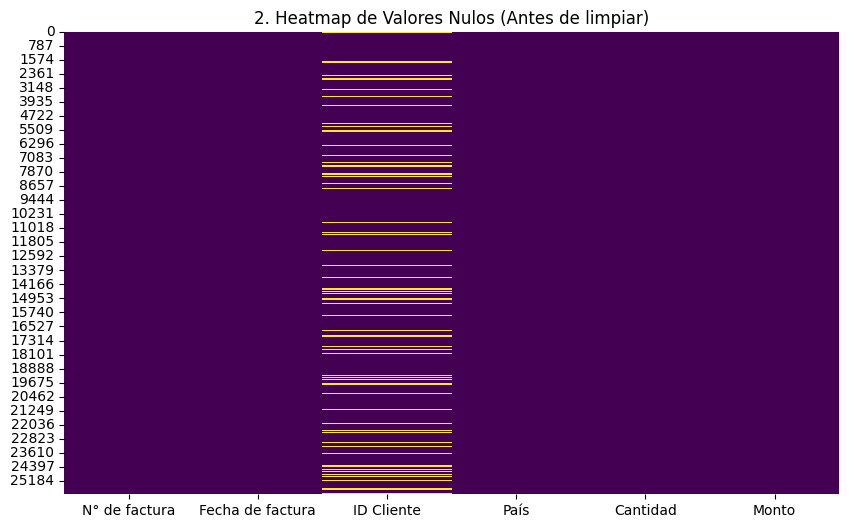

In [16]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("2. Heatmap de Valores Nulos (Antes de limpiar)")
plt.show()

In [17]:
duplicados = df.duplicated().sum()
print(f"\nSe encontraron {duplicados} filas duplicadas.")


Se encontraron 10 filas duplicadas.


In [18]:
outliers_cantidad = len(df[df['Cantidad'] <= 0])
print(f"Facturas con cantidades nulas o negativas (Outliers): {outliers_cantidad}")

Facturas con cantidades nulas o negativas (Outliers): 5179


In [31]:
facturas_canceladas = df[df['N° de factura'].astype(str).str.upper().str.startswith('C')]
print(f"Se encontraron {len(facturas_canceladas)} facturas canceladas (letra C).")

Se encontraron 3841 facturas canceladas (letra C).


In [32]:
df_limpio = df_limpio[~df_limpio['N° de factura'].astype(str).str.upper().str.startswith('C')]

In [19]:
df['Monto'] = df['Monto'].astype(str).str.replace('"', '').str.replace(',', '.').astype(float)
df['Fecha de factura'] = pd.to_datetime(df['Fecha de factura'])

In [20]:
df_limpio = df.drop_duplicates().copy()

In [21]:
df_limpio = df_limpio.dropna(subset=['ID Cliente'])

In [22]:
df_limpio = df_limpio[(df_limpio['Cantidad'] > 0) & (df_limpio['Monto'] > 0)]

In [23]:
print("Limpieza terminada. Tamaño del dataset original vs limpio:")
print(f"Original: {df.shape} -> Limpio: {df_limpio.shape}")

Limpieza terminada. Tamaño del dataset original vs limpio:
Original: (25953, 6) -> Limpio: (18562, 6)


In [24]:
ventas_pais = df_limpio.groupby('País')['Monto'].sum().sort_values(ascending=False).head(10)

/tmp/ipykernel_918/209571024.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_pais.values, y=ventas_pais.index, palette='magma')


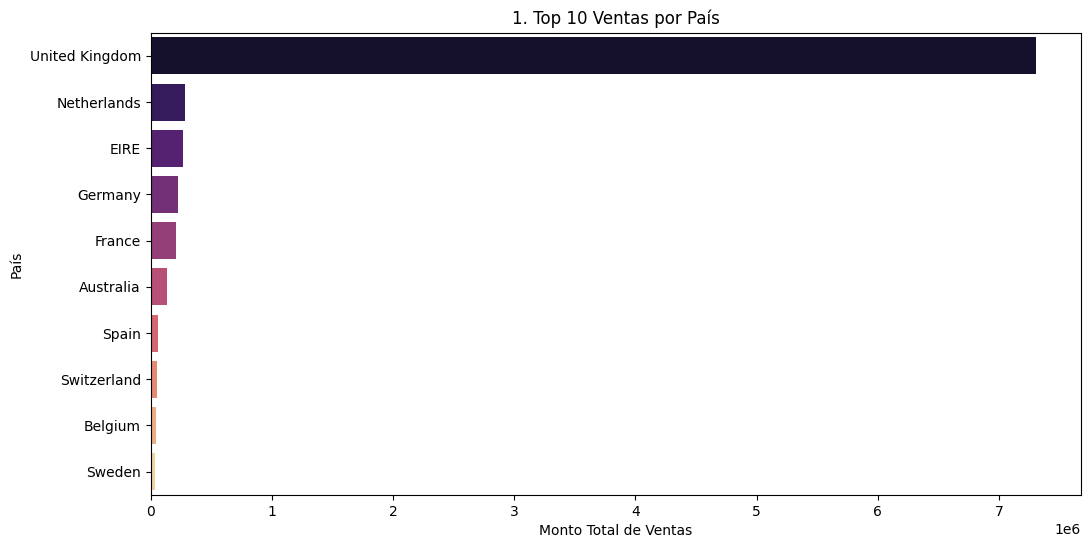

In [25]:
plt.figure(figsize=(12, 6))
sns.barplot(x=ventas_pais.values, y=ventas_pais.index, palette='magma')
plt.title("1. Top 10 Ventas por País")
plt.xlabel("Monto Total de Ventas")
plt.ylabel("País")
plt.show()

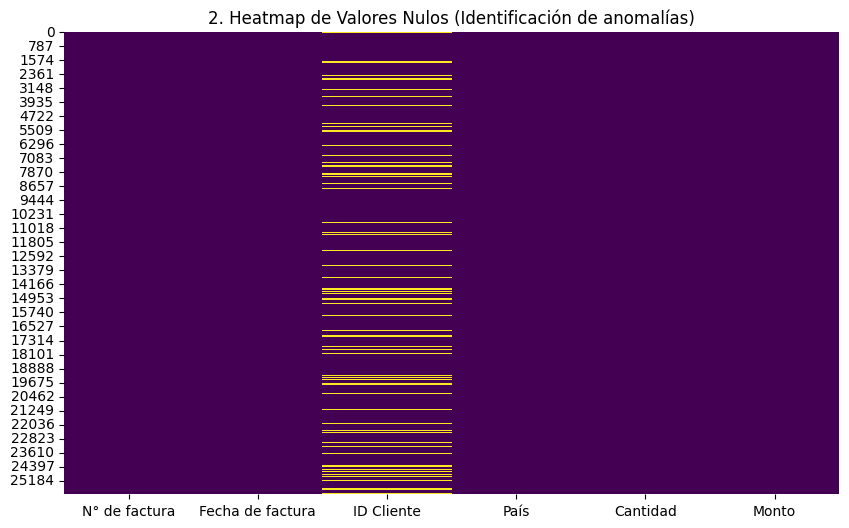

In [29]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("2. Heatmap de Valores Nulos (Identificación de anomalías)")
plt.show()

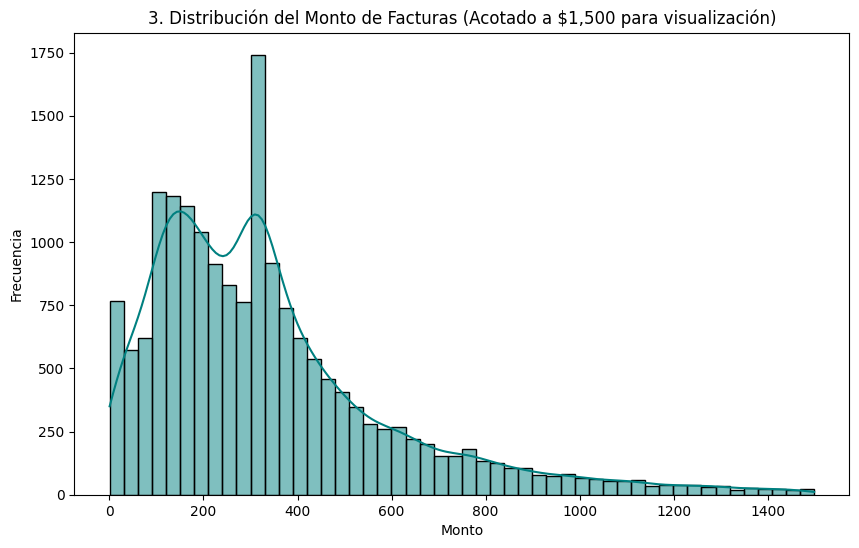

In [26]:
plt.figure(figsize=(10, 6))
sns.histplot(df_limpio[df_limpio['Monto'] < 1500]['Monto'], bins=50, kde=True, color='teal')
plt.title("3. Distribución del Monto de Facturas (Acotado a $1,500 para visualización)")
plt.xlabel("Monto")
plt.ylabel("Frecuencia")
plt.show()

## Justificación y Principio GIGO

**Justificación de decisiones tomadas:**
*  Se decidió eliminar los registros que contenían números negativos o formatos nulos  en las Cantidades, ya que representaban cancelaciones o errores de captura que alterarían la suma real de las ventas totales.
* Modificar el tipo de dato de `Monto` a `float` era estrictamente necesario para que Pandas pudiera calcular totales y generar los histogramas.

**¿Cómo afecta el principio GIGO (Garbage In, Garbage Out)?**
[cite_start]El principio GIGO establece que la calidad de los resultados de un análisis o de un modelo de *Machine Learning* será tan buena como la calidad de sus datos de entrada.

[cite_start]Si no hubiéramos limpiado este dataset, el modelo habría interpretado montos como el `"229,33"` como texto en lugar de números, arrojando errores o sumas completamente desviadas. Además, mantener facturas con cantidades negativas (basura) habría hecho creer a nuestro modelo que las ventas globales del negocio son mucho menores a la realidad. Los datos sucios generan predicciones incorrectas y, por ende, malas decisiones de negocio.

In [34]:
df_limpio.to_csv('ventas_limpias.csv', index=False)